In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
#importing cell

import CommunityModelClass3 as cmc3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from statistics import mode

save_directory = "stability_time"
isExist = os.path.exists(save_directory)
if not isExist:
    os.makedirs(save_directory)

In [8]:
def gen_statistics(N_sim,inputs):
    t_species = np.zeros(N_sim)
    t_resources = np.zeros (N_sim)
    for i in range(N_sim):
        print("epoch:", i, end="\r")
        model = cmc3.CommunityModel(inputs)
        model.Simulate()
        t_species[i] = model.StabilityTime("species",Plots=False)
        t_resources[i] = model.StabilityTime("resources",Plots=False)
    return np.array([t_species,t_resources])

In [9]:
inputs={}

inputs["S_tot"] = 80
inputs["S"] = 40
inputs["R"] = 40

# initial conditions
inputs["S0"] = 10
inputs["R0"] = 5

# time simulation params
inputs["time_period"] = 1e5
inputs["t_step"] = 0.1

# partitions params
inputs["num_F"] = 4
inputs["num_T"] = 4
inputs["partition_F"] = [20]*4
inputs["partition_T"] = [10]*4

# activation function
inputs["sigma_type"] = "linear"
inputs["k"] = 20                           
inputs["N"] = 2

# h function params (external energy flux)
inputs["tau_R"] = 1
inputs["k_alpha_index"] = 0


# metabolic matrix params
inputs["f_c"] = 0.25
inputs["f_s"] = 0.25
inputs["d0"] = 0.2

# preference matrix params
inputs["preference_type"] = "binary"
inputs["mu_c"] = 4.5
inputs["sigma_c"] = 1
inputs["c_0"] = 1
inputs["c_1"] = 1
inputs["q_A"] = 0.5

## Diverse Regime ($l$=0.8, $w_0k_0=1000$):

In [84]:
inputs["leakage"] = 0.8
inputs["k_0"] = 1000

N_sim = 250

#DR_results = gen_statistics(N_sim, inputs)
#pd.DataFrame(DR_results[0]).to_csv(save_directory+"/DR_spec_time.csv",index=False,header=False)
#pd.DataFrame(DR_results[1]).to_csv(save_directory+"/DR_res_time.csv",index=False,header=False)

DR_spec = np.genfromtxt(save_directory+"/DR_spec_time.csv")
DR_res = np.genfromtxt(save_directory+"/DR_res_time.csv")

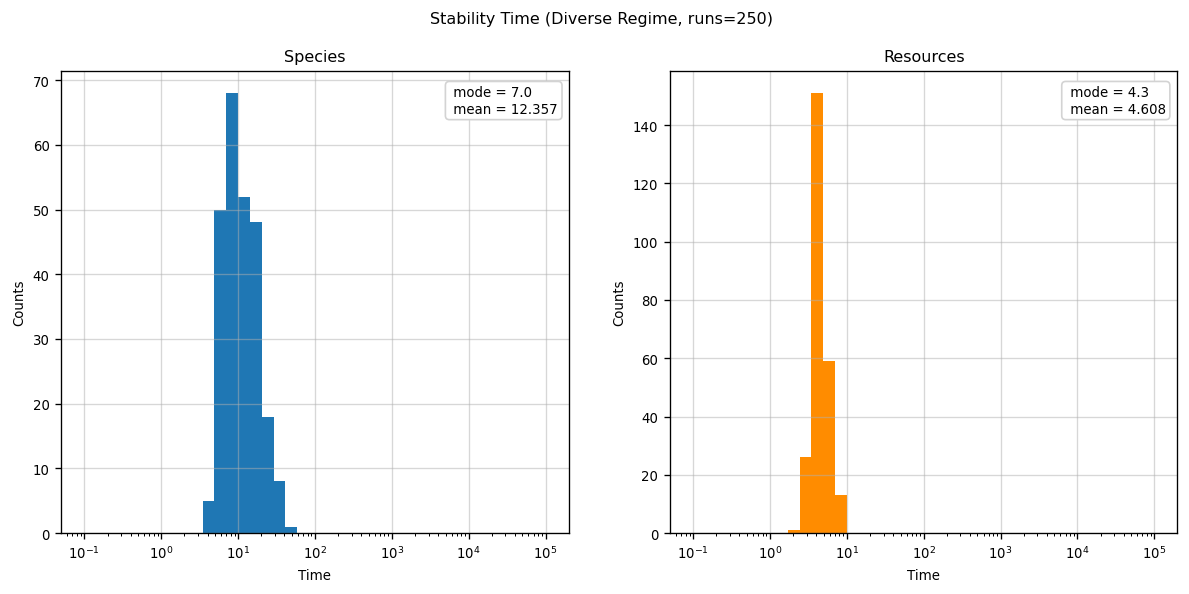

In [85]:
DR_spec_mode = np.round(mode(DR_spec),3)
DR_res_mode = np.round(mode(DR_res),3)
DR_spec_mean = np.round(np.mean(DR_spec),3)
DR_res_mean = np.round(np.mean(DR_res),3)

bins=np.logspace(np.log10(0.1),np.log10(inputs["time_period"]), 40)

fig, ax = plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Stability Time (Diverse Regime, runs={})".format(N_sim))

ax[0].set(title="Species",xlabel="Time",ylabel="Counts")
ax[0].hist(DR_spec,bins=bins)
ax[0].set_xscale("log")
ax[0].text(-0.435,0.91, " mode = {} \n mean = {}".format(DR_spec_mode,DR_spec_mean),fontsize=8,bbox=dict(facecolor='white', edgecolor='lightgrey',boxstyle='round,pad=0.3'),transform=plt.gca().transAxes)
ax[0].grid(alpha=0.5)

ax[1].set(title="Resources",xlabel="Time",ylabel="Counts")
ax[1].hist(DR_res,bins=bins,color="darkorange")
ax[1].set_xscale("log")
ax[1].text(0.78,0.91, " mode = {} \n mean = {}".format(DR_res_mode,DR_res_mean),fontsize=8,bbox=dict(facecolor='white', edgecolor='lightgrey',boxstyle='round,pad=0.3'),transform=plt.gca().transAxes)
ax[1].grid(alpha=0.5);

## Resource-limited Regime ($l$=0.001, $w_0k_0=10$):

In [86]:
inputs["leakage"] = 0.001
inputs["k_0"] = 10

N_sim = 250

#LR_results = gen_statistics(N_sim, inputs)
#pd.DataFrame(LR_results[0]).to_csv(save_directory+"/LR_spec_time.csv",index=False,header=False)
#pd.DataFrame(LR_results[1]).to_csv(save_directory+"/LR_res_time.csv",index=False,header=False)

LR_spec = np.genfromtxt(save_directory+"/LR_spec_time.csv")
LR_res = np.genfromtxt(save_directory+"/LR_res_time.csv")

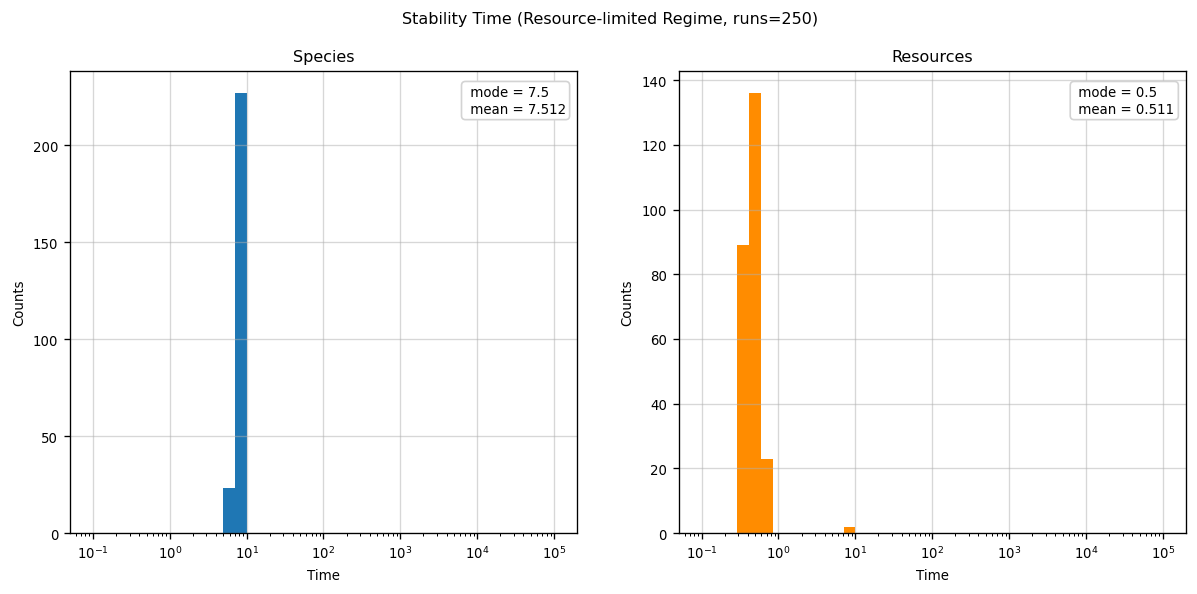

In [87]:
LR_spec_mode = np.round(mode(LR_spec),3)
LR_res_mode = np.round(mode(LR_res),3)
LR_spec_mean = np.round(np.mean(LR_spec),3)
LR_res_mean = np.round(np.mean(LR_res),3)

bins=np.logspace(np.log10(0.1),np.log10(inputs["time_period"]), 40)

fig, ax = plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Stability Time (Resource-limited Regime, runs={})".format(N_sim))

ax[0].set(title="Species",xlabel="Time",ylabel="Counts")
ax[0].hist(LR_spec,bins=bins)
ax[0].set_xscale("log")
ax[0].text(-0.42,0.91, " mode = {} \n mean = {}".format(LR_spec_mode,LR_spec_mean),fontsize=8,bbox=dict(facecolor='white', edgecolor='lightgrey',boxstyle='round,pad=0.3'),transform=plt.gca().transAxes)
ax[0].grid(alpha=0.5)

ax[1].set(title="Resources",xlabel="Time",ylabel="Counts")
ax[1].hist(LR_res,bins=bins,color="darkorange")
ax[1].set_xscale("log")
ax[1].text(0.78,0.91, " mode = {} \n mean = {}".format(LR_res_mode,LR_res_mean),fontsize=8,bbox=dict(facecolor='white', edgecolor='lightgrey',boxstyle='round,pad=0.3'),transform=plt.gca().transAxes)
ax[1].grid(alpha=0.5)


## Comparison between the two regimes

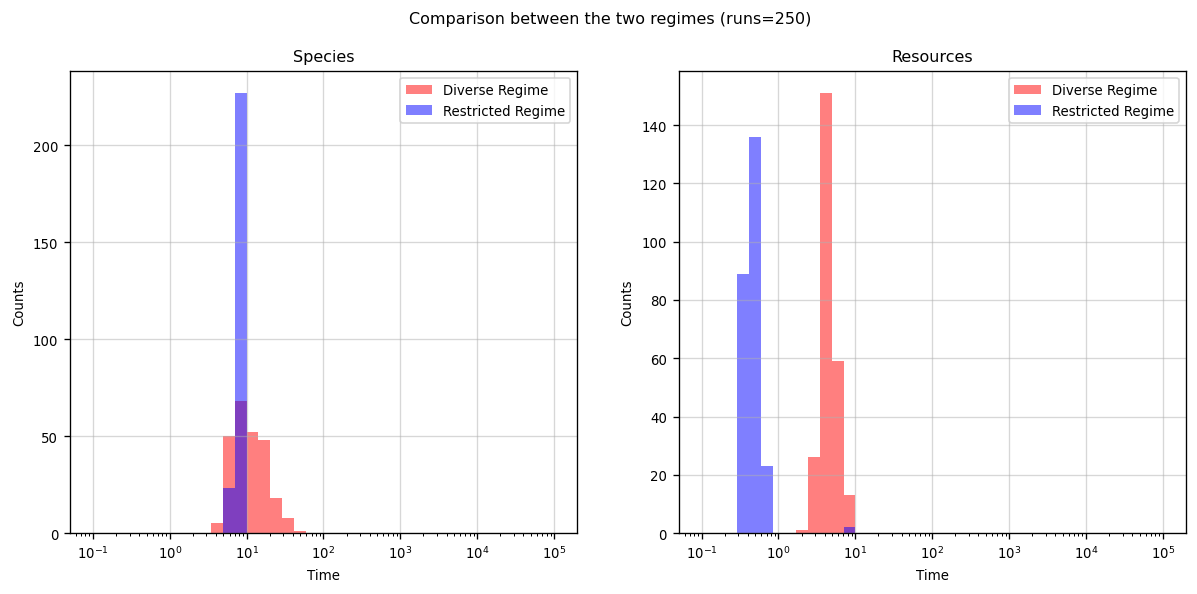

In [88]:
bins=np.logspace(np.log10(0.1),np.log10(inputs["time_period"]), 40)

fig, ax = plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Comparison between the two regimes (runs={})".format(N_sim))

ax[0].set(title="Species",xlabel="Time",ylabel="Counts")
ax[0].hist(DR_spec,bins=bins,label="Diverse Regime",alpha=0.5,color="red")
ax[0].hist(LR_spec,bins=bins,label="Restricted Regime",alpha=0.5,color="blue")
ax[0].set_xscale("log")
ax[0].grid(alpha=0.5)
ax[0].legend()

ax[1].set(title="Resources",xlabel="Time",ylabel="Counts")
ax[1].hist(DR_res,bins=bins,label="Diverse Regime",alpha=0.5,color="red")
ax[1].hist(LR_res,bins=bins,label="Restricted Regime",alpha=0.5,color="blue")
ax[1].set_xscale("log")
ax[1].grid(alpha=0.5)
ax[1].legend();